# PBMF — ensemble + consensus pruning (step 4)

Train M = 1000 bagged models (paper recommends ≥20; 1000 keeps ~50 after pruning), then prune to the ~50 models whose patient splits agree with the crowd. Aggregate with a plain mean.

**Ensemble design (POPLAR/OAK config, from the paper's supplement Table S2):**
- patient bag: 80% of patients per model
- per-step dropout: 10% of the bag resampled out at each gradient step
- feature bag: 28 of 29 features
- 500 gradient steps, lr = 0.01, hidden = 64
- **λ_control = 0** — the control-arm penalty is off for this study; ensemble diversity + pruning carry the predictive constraint
- sign correction: after training each model, check if its channel-1 scores give Z(atezo) > 0 (i.e. B+ does *worse* on atezo); if so, flip

**Pruning (consensus):**

`R` (N×M): binary B+ assignments after sign correction.

`A` (N×N): co-assignment matrix, `A[i,j]` = fraction of models that put patients i and j in the same group.

`C` (N×M): `C[i,m]` = Pearson correlation between patient i's co-assignment profile and model m's assignments. High `C[i,m]` means model m's partition looks like the consensus partition anchored at i.

Threshold C at its 95th percentile → per-patient-per-model agreement mask. Sum over patients per model → agreement count. Keep models whose count exceeds the 95th percentile. With M=1000 this typically leaves ~50 models.

Nothing in pruning looks at survival labels beyond what each trained model already encodes — so it is not a form of held-out-label cheating.

**Evaluation:** train on POPLAR, validate on OAK. Pruning uses POPLAR training scores only.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from pbmf import (
    build_features, evaluate_biomarker, plot_km_strata,
    train_pbmf_ensemble, score_ensemble, prune_ensemble,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3g}")

feat, genes = build_features()
feat = feat.dropna(subset=["OS", "OS_event", "blSLD"]).reset_index(drop=True)

clinical_cols = ["age", "sex_M", "ecog", "blSLD", "metsites",
                 "hist_squamous", "ever_smoker", "msaf", "btmb"]
mut_cols = [c for c in feat.columns if c.startswith("mut_")]

poplar_mask = feat["Trial"].values == "POPLAR"
oak_mask    = feat["Trial"].values == "OAK"

# Fit scaler on POPLAR (training) only, then apply to all patients — no held-out leakage.
scaler = StandardScaler().fit(feat.loc[poplar_mask, clinical_cols])
X = np.hstack([
    scaler.transform(feat[clinical_cols]),
    feat[mut_cols].values,
]).astype(np.float32)
times  = feat["OS"].values.astype(np.float32)
events = feat["OS_event"].values.astype(np.int64)
arm    = (feat["TRT01P"] == "Atezolizumab").astype(int).values

print(f"POPLAR (train): {poplar_mask.sum()}")
print(f"OAK (held-out): {oak_mask.sum()}")
print(f"Features: {X.shape[1]} ({len(clinical_cols)} clinical + {len(mut_cols)} genes)")


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jaschabeste/repositories/pbmf-reproduction/pbmf/data.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.read_excel(xlsx_path, sheet_name=sheet).replace({".": np.nan})


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/jaschabeste/repositories/pbmf-reproduction/pbmf/data.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.read_excel(xlsx_path, sheet_name=sheet).replace({".": np.nan})


POPLAR (train): 211
OAK (held-out): 641
Features: 29 (9 clinical + 20 genes)


/Users/jaschabeste/repositories/pbmf-reproduction/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [ ]:
t0 = time.time()
ensemble = train_pbmf_ensemble(
    X[poplar_mask], times[poplar_mask], events[poplar_mask], arm[poplar_mask],
    M=1000,
    steps=500,
    lr=1e-2,
    patient_bag=0.8,
    n_features=X.shape[1] - 1,
    ifrac=0.1,
    lam_control=0.0,
    seed=0,
    verbose=200,
)
print(f"trained {len(ensemble)} models in {time.time() - t0:.1f}s")
print(f"sign-flipped: {sum(e['flip'] for e in ensemble)}/{len(ensemble)}")

Kept 48/1000 models after 95th-percentile pruning
  C threshold: 0.819
  count threshold: 95.0
  Kept model indices: [60, 80, 112, 117, 127, 185, 278, 285, 324, 343, 367, 466, 472, 495, 504, 541, 559, 567, 593, 607, 616, 629, 668, 674, 676, 706, 714, 727, 743, 744, 750, 788, 814, 827, 862, 867, 873, 876, 877, 890, 891, 920, 922, 924, 939, 954, 965, 987]


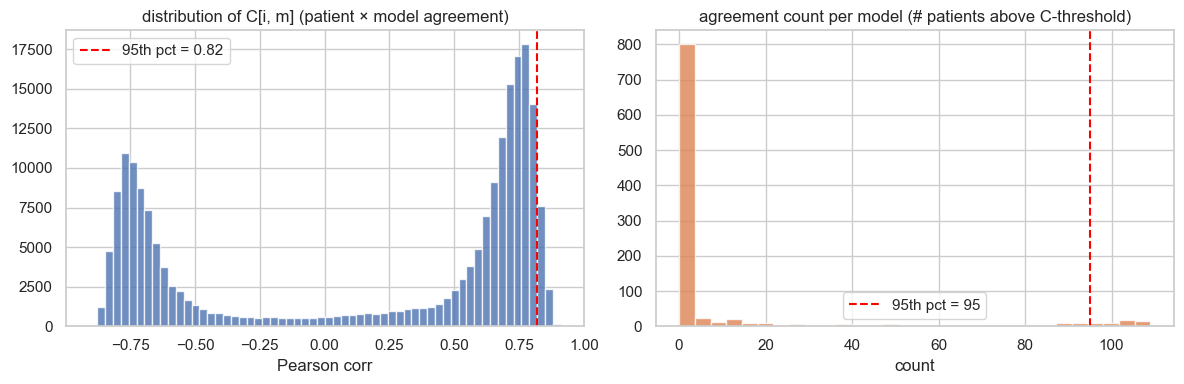

In [3]:
poplar_scores = score_ensemble(ensemble, X[poplar_mask])
oak_scores    = score_ensemble(ensemble, X[oak_mask])

kept, diag = prune_ensemble(poplar_scores, percentile=95)
print(f"Kept {len(kept)}/{len(ensemble)} models after 95th-percentile pruning")
print(f"  C threshold: {diag['c_thresh']:.3f}")
print(f"  count threshold: {diag['count_thresh']:.1f}")
print(f"  Kept model indices: {kept.tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(diag["C"].ravel(), bins=60, color="C0", alpha=0.8)
axes[0].axvline(diag["c_thresh"], color="red", linestyle="--", label=f"95th pct = {diag['c_thresh']:.2f}")
axes[0].set_title("distribution of C[i, m] (patient × model agreement)")
axes[0].set_xlabel("Pearson corr"); axes[0].legend()
axes[1].hist(diag["counts"], bins=30, color="C1", alpha=0.8)
axes[1].axvline(diag["count_thresh"], color="red", linestyle="--",
                label=f"95th pct = {diag['count_thresh']:.0f}")
axes[1].set_title("agreement count per model (# patients above C-threshold)")
axes[1].set_xlabel("count"); axes[1].legend()
plt.tight_layout()

## Pre-pruning vs post-pruning — held-out OAK

Mean ensemble score → 0/1 label at threshold 0.5 → `evaluate_biomarker`.

In [4]:
def eval_and_row(mask, scores_subset, label):
    df = feat[mask].copy()
    mean = scores_subset.mean(axis=1)
    df["bplus"] = (mean >= 0.5).astype(int)
    df["score"] = mean
    r = evaluate_biomarker(df, label_col="bplus").as_series()
    r["B+ rate"] = f"{df['bplus'].mean():.1%}"
    r.name = label
    return df, r

rows = []
_, r = eval_and_row(poplar_mask, poplar_scores,             "POPLAR train, pre-prune");  rows.append(r)
_, r = eval_and_row(oak_mask,    oak_scores,                "OAK held, pre-prune");      rows.append(r)
poplar_df, r = eval_and_row(poplar_mask, poplar_scores[:, kept], "POPLAR train, post-prune"); rows.append(r)
oak_df,    r = eval_and_row(oak_mask,    oak_scores[:, kept],    "OAK held, post-prune");     rows.append(r)

# Add bTMB>=16 baseline on OAK for context
btmb_base = feat[oak_mask].copy()
btmb_base["bplus"] = (btmb_base["btmb"] >= 16).astype(int)
r = evaluate_biomarker(btmb_base, label_col="bplus").as_series()
r["B+ rate"] = f"{btmb_base['bplus'].mean():.1%}"
r.name = "OAK held, bTMB≥16"
rows.append(r)

pd.DataFrame(rows)

,n_B+,n_B-,HR(Tx|B+),CI(Tx|B+),p(Tx|B+),HR(Tx|B-),CI(Tx|B-),p(Tx|B-),HR+/HR-,p(interaction),B+ rate
"POPLAR train, pre-prune",134,77,0.383,"[0.25, 0.60]",2.05e-05,2.47,"[1.50, 4.06]",0.000369,0.155,2.5e-08,63.5%
"OAK held, pre-prune",444,197,0.617,"[0.49, 0.78]",3.36e-05,0.795,"[0.58, 1.08]",0.148,0.776,0.251,69.3%
"POPLAR train, post-prune",140,71,0.444,"[0.29, 0.68]",0.000159,2.06,"[1.26, 3.36]",0.00397,0.216,4.18e-06,66.4%
"OAK held, post-prune",475,166,0.585,"[0.47, 0.73]",1.69e-06,1.01,"[0.72, 1.41]",0.955,0.58,0.0103,74.1%
"OAK held, bTMB≥16",160,481,0.622,"[0.43, 0.90]",0.0121,0.684,"[0.55, 0.85]",0.000442,0.91,0.48,25.0%


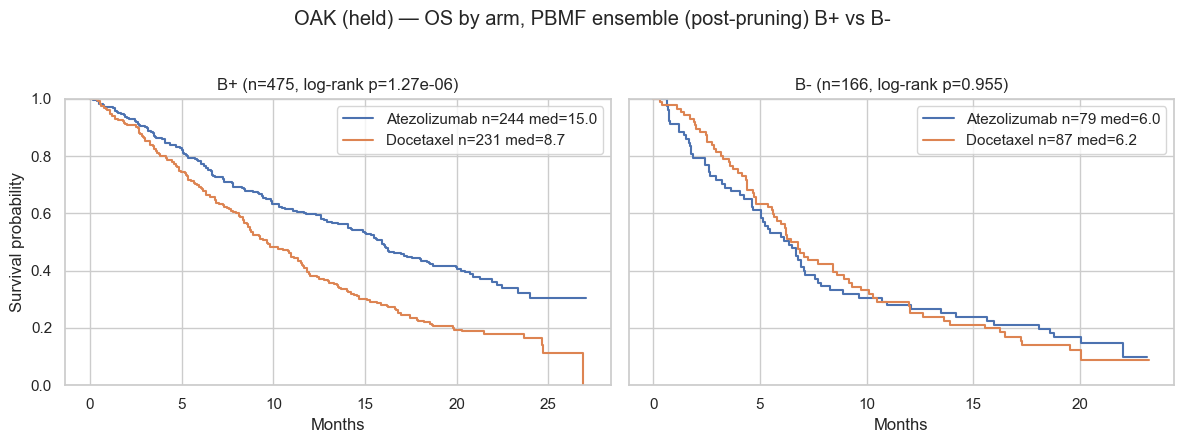

In [5]:
plot_km_strata(oak_df, label_col="bplus",
               title="OAK (held) — OS by arm, PBMF ensemble (post-pruning) B+ vs B-")
plt.show()

## Score distribution + comparison to bTMB

Is the ensemble score mostly a re-learning of bTMB, or is it using other features?

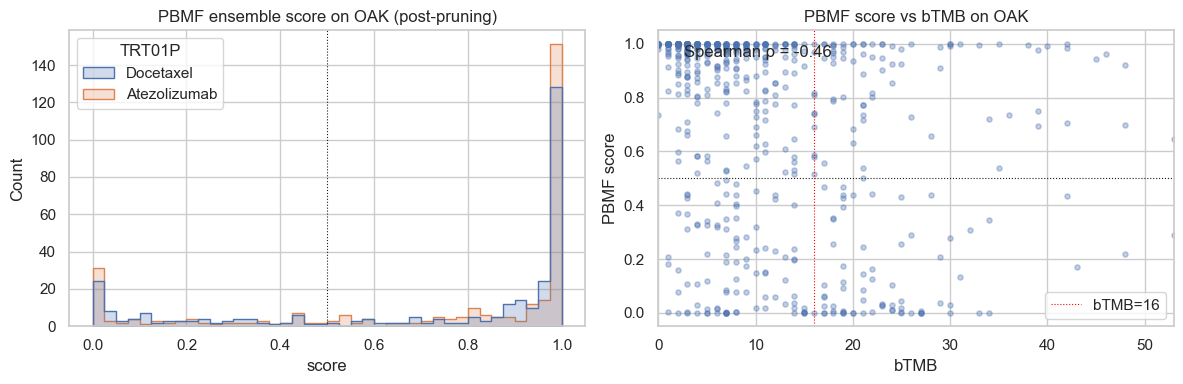

In [6]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(oak_df, x="score", hue="TRT01P", bins=40, ax=axes[0], element="step")
axes[0].axvline(0.5, color="k", linestyle=":", linewidth=0.8)
axes[0].set_title("PBMF ensemble score on OAK (post-pruning)")

axes[1].scatter(oak_df["btmb"], oak_df["score"], alpha=0.35, s=14)
axes[1].set_xlim(0, oak_df["btmb"].quantile(0.99))
axes[1].axhline(0.5, color="k", linestyle=":", linewidth=0.8)
axes[1].axvline(16,  color="red", linestyle=":", linewidth=0.8, label="bTMB=16")
rho, _ = spearmanr(oak_df["btmb"], oak_df["score"])
axes[1].text(0.05, 0.95, f"Spearman ρ = {rho:.2f}", transform=axes[1].transAxes, va="top")
axes[1].set_xlabel("bTMB"); axes[1].set_ylabel("PBMF score")
axes[1].set_title("PBMF score vs bTMB on OAK")
axes[1].legend()
plt.tight_layout()

## Stability across random seeds

Train 2 more ensembles with different seeds to see if the held-out numbers are stable or seed-dependent.

In [7]:
rows = []
for seed in [1, 2]:
    ens = train_pbmf_ensemble(
        X[poplar_mask], times[poplar_mask], events[poplar_mask], arm[poplar_mask],
        M=1000, steps=500, lr=1e-2, patient_bag=0.8,
        n_features=X.shape[1]-1, ifrac=0.1, lam_control=0.0, seed=seed,
    )
    ps = score_ensemble(ens, X[poplar_mask])
    os_ = score_ensemble(ens, X[oak_mask])
    kept_s, _ = prune_ensemble(ps, percentile=95)

    df = feat[oak_mask].copy()
    df["bplus"] = (os_[:, kept_s].mean(axis=1) >= 0.5).astype(int)
    r = evaluate_biomarker(df, label_col="bplus").as_series()
    r["seed"] = seed
    r["n_kept"] = len(kept_s)
    r["B+ rate"] = f"{df['bplus'].mean():.1%}"
    rows.append(r)
    print(f"seed={seed}  kept={len(kept_s)}  B+={df['bplus'].mean():.2%}  "
          f"HR+/HR-={r['HR+/HR-']:.3f}  int p={r['p(interaction)']:.3g}")

pd.DataFrame(rows).set_index("seed")

seed=1  kept=47  B+=73.17%  HR+/HR-=0.638  int p=0.0333


seed=2  kept=50  B+=74.88%  HR+/HR-=0.557  int p=0.00486


,n_B+,n_B-,HR(Tx|B+),CI(Tx|B+),p(Tx|B+),HR(Tx|B-),CI(Tx|B-),p(Tx|B-),HR+/HR-,p(interaction),n_kept,B+ rate
seed,,,,,,,,,,,,
1,469,172,0.589,"[0.47, 0.73]",2.83e-06,0.923,"[0.66, 1.28]",0.632,0.638,0.0333,47,73.2%
2,480,161,0.585,"[0.47, 0.73]",1.54e-06,1.05,"[0.75, 1.48]",0.772,0.557,0.00486,50,74.9%
